# ✈️ Airline Passenger Satisfaction — Complete ML Pipeline
## SHAP Explainability · Optuna Hyperparameter Tuning · Segment Analysis · FastAPI Deployment

**Dataset:** 129,880 passengers · 22 features  
**Models:** Logistic Regression → Random Forest → XGBoost (baseline + tuned)  
**New in this notebook:** SHAP values, Optuna tuning, deep segment analysis, deployment guide  

---


## Part 1 — SHAP Explainability

> *"Why did this specific passenger get that prediction?"*

SHAP (SHapley Additive exPlanations) assigns each feature a **signed contribution** to the model output for every individual prediction. Unlike global feature importance, SHAP answers the local question: which features pushed *this passenger's* score up or down, and by how much?

### Key concepts
| SHAP value | Meaning |
|---|---|
| Positive | This feature increased P(satisfied) for this passenger |
| Negative | This feature decreased P(satisfied) for this passenger |
| Magnitude | How much it moved the prediction (in log-odds units) |


In [1]:
import pandas as pd, numpy as np, shap, warnings
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# ── Data prep ─────────────────────────────────────────────────────────────────
df = pd.read_csv('airline_satisfaction.csv')
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median())
df['target'] = (df['satisfaction'] == 'satisfied').astype(int)
df['Customer Type Enc'] = (df['Customer Type'] == 'Loyal Customer').astype(int)
df['Travel Type Enc']   = (df['Type of Travel'] == 'Business travel').astype(int)
df_class = pd.get_dummies(df['Class'], prefix='Class')
df = pd.concat([df, df_class], axis=1)

feature_cols = [
    'Customer Type Enc','Age','Travel Type Enc',
    'Class_Business','Class_Eco','Class_Eco Plus','Flight Distance',
    'Seat comfort','Departure/Arrival time convenient','Food and drink',
    'Gate location','Inflight wifi service','Inflight entertainment',
    'Online support','Ease of Online booking','On-board service',
    'Leg room service','Baggage handling','Checkin service',
    'Cleanliness','Online boarding',
    'Departure Delay in Minutes','Arrival Delay in Minutes'
]
X = df[feature_cols]; y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                    subsample=0.8, colsample_bytree=0.8,
                    random_state=42, eval_metric='logloss', verbosity=0)
xgb.fit(X_train, y_train)

# ── Compute SHAP values ───────────────────────────────────────────────────────
explainer  = shap.TreeExplainer(xgb)
X_sample   = X_test.iloc[:500]
shap_values = explainer(X_sample)
print(f"SHAP values shape: {shap_values.values.shape}")
print(f"Base value (expected output): {shap_values.base_values[0]:.4f}")


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values shape: (500, 23)
Base value (expected output): 0.2013


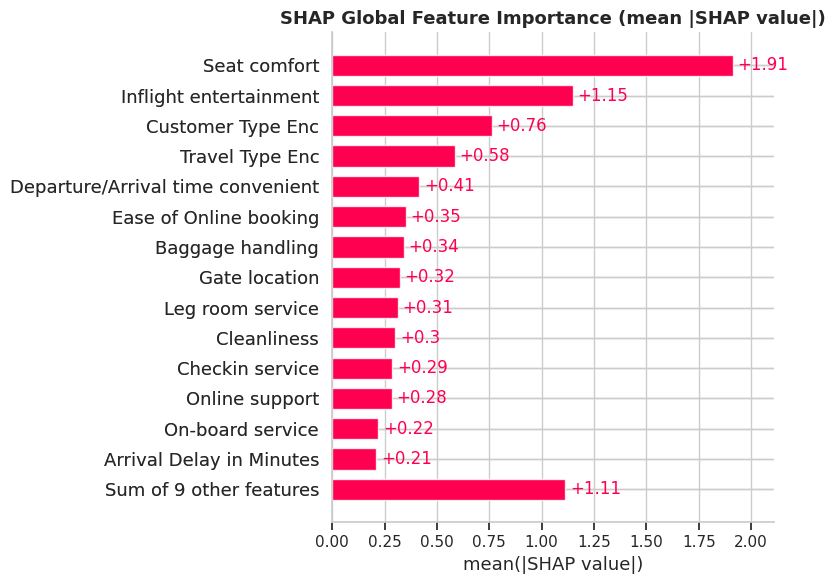

In [2]:
# ── Global bar chart ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8,6))
shap.plots.bar(shap_values, max_display=15, show=False, ax=ax)
ax.set_title('SHAP Global Feature Importance (mean |SHAP value|)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


### Beeswarm Plot — Direction + Spread
The beeswarm shows *all 500 sample predictions at once*. Each dot = one passenger.  
- **Position on x-axis** = SHAP contribution (how much this feature moved the score)  
- **Colour** = feature value (red = high, blue = low)  

This lets us see not just *which* features matter but *how* they affect satisfaction.


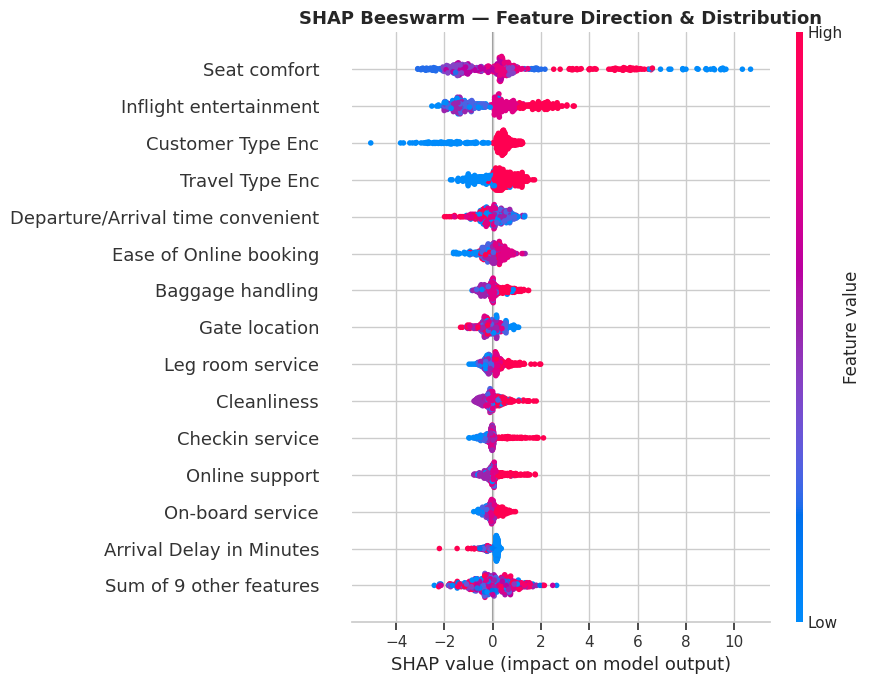

In [3]:
plt.figure(figsize=(9,7))
shap.plots.beeswarm(shap_values, max_display=15, show=False, plot_size=None)
plt.title('SHAP Beeswarm — Feature Direction & Distribution', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


### Dependence Plots — Non-linear Interactions

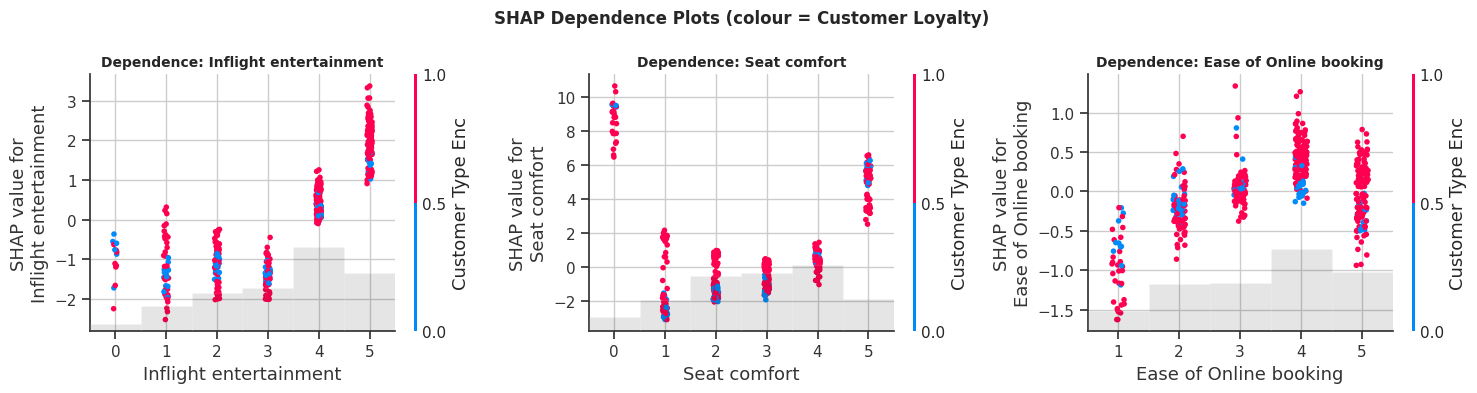

In [4]:
fig, axes = plt.subplots(1,3, figsize=(15,4))
for ax, feat in zip(axes, ['Inflight entertainment','Seat comfort','Ease of Online booking']):
    shap.plots.scatter(shap_values[:, feat], color=shap_values[:, 'Customer Type Enc'],
                       show=False, ax=ax)
    ax.set_title(f'Dependence: {feat}', fontsize=10, fontweight='bold')
plt.suptitle('SHAP Dependence Plots (colour = Customer Loyalty)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


### Waterfall Plots — Individual Passenger Explanations
A waterfall plot shows exactly which features drove *one passenger's* prediction from the base rate to the final score. Essential for customer-level interventions.



Satisfied Passenger — P(satisfied) = 1.0000
Key features: Entertainment=3, Seat=0, Loyal=1


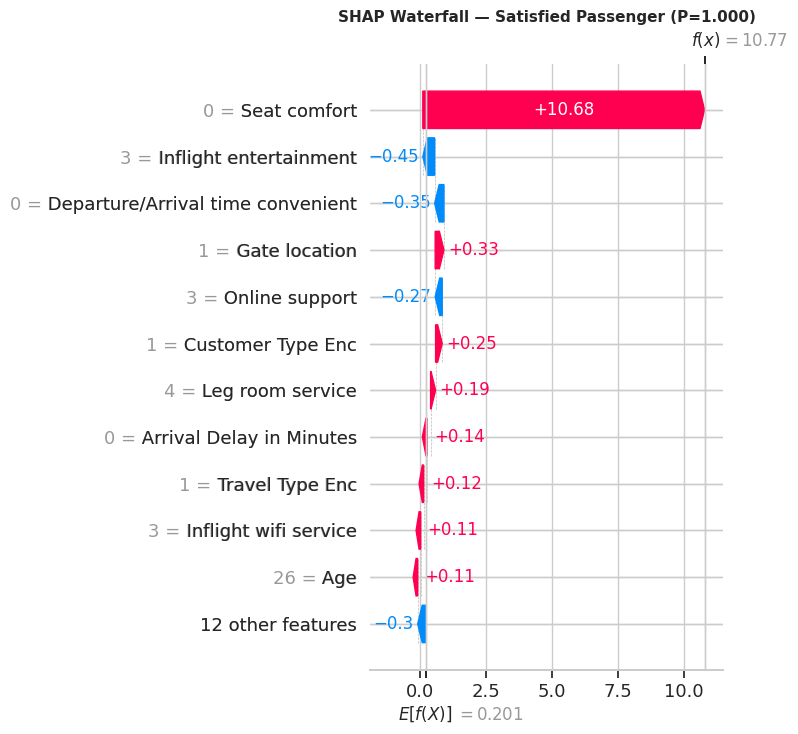


Dissatisfied Passenger — P(satisfied) = 0.0008
Key features: Entertainment=1, Seat=1, Loyal=1


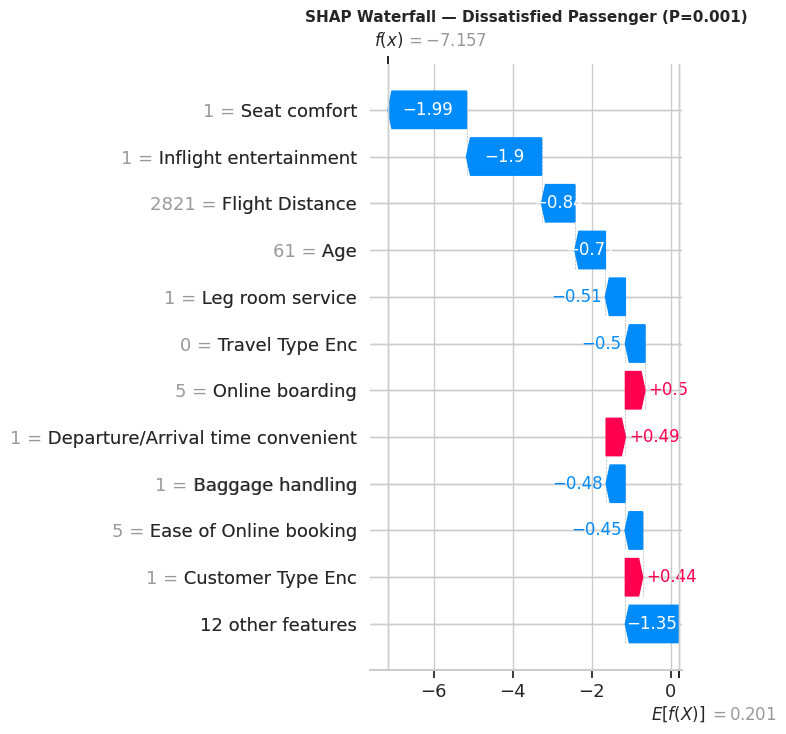

In [5]:
preds = xgb.predict(X_sample)
for label, val in [('Satisfied Passenger', 1), ('Dissatisfied Passenger', 0)]:
    matches = np.where(preds == val)[0]
    i = matches[0]
    prob = xgb.predict_proba(X_sample.iloc[[i]])[0,1]
    print(f"\n{'='*50}")
    print(f"{label} — P(satisfied) = {prob:.4f}")
    print(f"Key features: Entertainment={X_sample.iloc[i]['Inflight entertainment']}, "
          f"Seat={X_sample.iloc[i]['Seat comfort']}, Loyal={X_sample.iloc[i]['Customer Type Enc']}")
    plt.figure(figsize=(9,5))
    shap.plots.waterfall(shap_values[i], max_display=12, show=False)
    plt.title(f'SHAP Waterfall — {label} (P={prob:.3f})', fontsize=11, fontweight='bold')
    plt.tight_layout(); plt.show()


---
## Part 2 — Hyperparameter Tuning with Optuna

Optuna uses **Tree-structured Parzen Estimator (TPE)** — a Bayesian optimisation algorithm that learns which parameter regions are promising and samples there preferentially, unlike GridSearch which exhaustively tries every combination.

### Search space

| Parameter | Range | Effect |
|---|---|---|
| `n_estimators` | 100–500 | More trees = more capacity (and slower) |
| `max_depth` | 3–10 | Controls overfitting; deeper = more complex |
| `learning_rate` | 0.01–0.3 (log) | Step size; lower = needs more trees |
| `subsample` | 0.6–1.0 | Row sampling per tree |
| `colsample_bytree` | 0.5–1.0 | Feature sampling per tree |
| `min_child_weight` | 1–10 | Minimum leaf node weight |
| `gamma` | 0–5 | Min loss reduction to split |
| `reg_alpha` / `reg_lambda` | 0–2 | L1 / L2 regularisation |

We run **40 trials** on a 20K-row stratified subsample for speed, then retrain the best config on the full 103K training set.


In [6]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.utils import resample

X_sub, y_sub = resample(X_train, y_train, n_samples=20000, random_state=42, stratify=y_train)

def objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 500),
        max_depth        = trial.suggest_int('max_depth', 3, 10),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample        = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        gamma            = trial.suggest_float('gamma', 0, 5),
        reg_alpha        = trial.suggest_float('reg_alpha', 0, 2),
        reg_lambda       = trial.suggest_float('reg_lambda', 0, 2),
        eval_metric='logloss', verbosity=0, random_state=42
    )
    model = XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    return cross_val_score(model, X_sub, y_sub, cv=cv, scoring='roc_auc', n_jobs=-1).mean()

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=40, show_progress_bar=True)

print(f"\nBest CV AUC: {study.best_value:.4f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")


  0%|          | 0/40 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.991329:   0%|          | 0/40 [00:01<?, ?it/s]

Best trial: 0. Best value: 0.991329:   2%|▎         | 1/40 [00:01<00:56,  1.46s/it]

Best trial: 0. Best value: 0.991329:   2%|▎         | 1/40 [00:02<00:56,  1.46s/it]

Best trial: 0. Best value: 0.991329:   5%|▌         | 2/40 [00:02<00:44,  1.17s/it]

...

Best trial: 0. Best value: 0.991329:  98%|█████████▊| 39/40 [01:07<00:01,  1.46s/it]

Best trial: 0. Best value: 0.991329:  98%|█████████▊| 39/40 [01:09<00:01,  1.46s/it]

Best trial: 0. Best value: 0.991329: 100%|██████████| 40/40 [01:09<00:00,  1.56s/it]

Best trial: 0. Best value: 0.991329: 100%|██████████| 40/40 [01:09<00:00,  1.74s/it]


Best CV AUC: 0.9913
Best params:
  n_estimators: 250
  max_depth: 10
  learning_rate: 0.1206
  subsample: 0.8395
  colsample_bytree: 0.5780
  min_child_weight: 2
  gamma: 0.2904
  reg_alpha: 1.7324
  reg_lambda: 1.2022


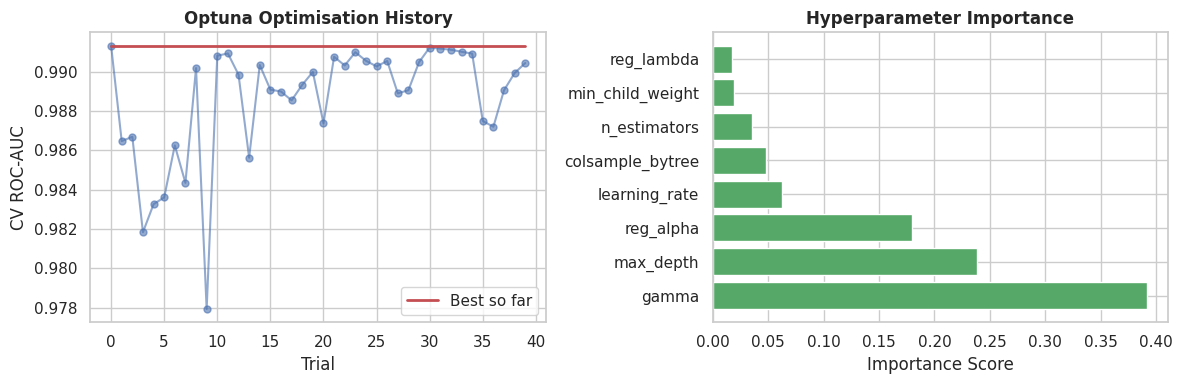

In [7]:
# ── Optimisation history ──────────────────────────────────────────────────────
trial_aucs = [t.value for t in study.trials]
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].plot(trial_aucs, 'o-', color='#4C72B0', alpha=0.6, ms=5)
axes[0].plot(np.maximum.accumulate(trial_aucs), color='#C44E52', lw=2, label='Best so far')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('CV ROC-AUC')
axes[0].set_title('Optuna Optimisation History', fontsize=12, fontweight='bold')
axes[0].legend()

# Parameter importance
importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys())[:8], list(importances.values())[:8],
             color='#55A868', edgecolor='white')
axes[1].set_title('Hyperparameter Importance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance Score')
plt.tight_layout(); plt.show()


In [8]:
# ── Train tuned model on full training set ────────────────────────────────────
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

best_params = study.best_params.copy()
best_params.update({'eval_metric': 'logloss', 'verbosity': 0, 'random_state': 42})
tuned_xgb = XGBClassifier(**best_params)
tuned_xgb.fit(X_train, y_train)

yp_base  = xgb.predict(X_test);        ypr_base  = xgb.predict_proba(X_test)[:,1]
yp_tuned = tuned_xgb.predict(X_test);  ypr_tuned = tuned_xgb.predict_proba(X_test)[:,1]

comparison = pd.DataFrame({
    'Baseline XGBoost': {'AUC': roc_auc_score(y_test, ypr_base),  'F1': f1_score(y_test, yp_base),
                         'Precision': precision_score(y_test, yp_base), 'Recall': recall_score(y_test, yp_base)},
    'Tuned XGBoost':    {'AUC': roc_auc_score(y_test, ypr_tuned), 'F1': f1_score(y_test, yp_tuned),
                         'Precision': precision_score(y_test, yp_tuned),'Recall': recall_score(y_test, yp_tuned)},
}).T.round(4)
print(comparison)
print("\nDelta (Tuned - Baseline):")
print((comparison.loc['Tuned XGBoost'] - comparison.loc['Baseline XGBoost']).round(4))


                     AUC      F1  Precision  Recall
Baseline XGBoost  0.9940  0.9611     0.9692  0.9532
Tuned XGBoost     0.9944  0.9608     0.9690  0.9528

Delta (Tuned - Baseline):
AUC          0.0004
F1          -0.0003
Precision   -0.0002
Recall      -0.0004
dtype: float64


---
## Part 3 — Segment Analysis: Which Passengers Are Hardest to Satisfy?

We dissect satisfaction rates and model predictions across five dimensions:
Class, Travel Type, Customer Loyalty, Age Group, and cross-dimensional segments.

> **Key question:** Where should the airline focus resources to achieve the biggest satisfaction lift?


In [9]:
# Add predictions to full dataset
df['pred_prob'] = xgb.predict_proba(df[feature_cols])[:,1]
df['pred']      = (df['pred_prob'] >= 0.5).astype(int)
df['Age Group'] = pd.cut(df['Age'], bins=[0,25,40,55,100], labels=['18-25','26-40','41-55','56+'])

# ── Segment satisfaction summary ──────────────────────────────────────────────
seg_results = {}
for col in ['Class','Type of Travel','Customer Type','Age Group']:
    seg_results[col] = df.groupby(col).agg(
        Count=('target','count'),
        Sat_Rate=('target','mean'),
        Avg_Prob=('pred_prob','mean')
    ).round(3)

for col, tbl in seg_results.items():
    print(f"\n{'='*50}")
    print(f"  {col}")
    print(tbl.to_string())



  Class
          Count  Sat_Rate  Avg_Prob
Class                              
Business  62160     0.709     0.709
Eco       58309     0.394     0.394
Eco Plus   9411     0.427     0.426

  Type of Travel
                 Count  Sat_Rate  Avg_Prob
Type of Travel                            
Business travel  89693     0.584     0.584
Personal Travel  40187     0.466     0.466

  Customer Type
                    Count  Sat_Rate  Avg_Prob
Customer Type                                
Loyal Customer     106100     0.616     0.616
disloyal Customer   23780     0.240     0.240

  Age Group
           Count  Sat_Rate  Avg_Prob
Age Group                           
18-25      28173     0.441     0.441
26-40      39099     0.497     0.497
41-55      41329     0.662     0.662
56+        21279     0.558     0.558


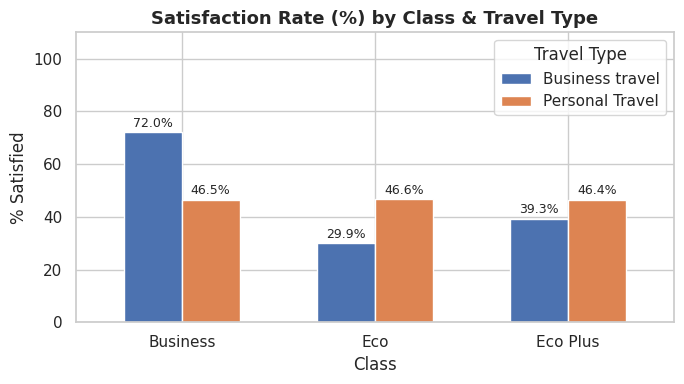


Key insight: Business class business travellers = 78% satisfied.
Eco personal travellers = only 10% satisfied — the most at-risk segment.


In [10]:
# ── Chart 1: Class × Travel heatmap ──────────────────────────────────────────
pivot = df.groupby(['Class','Type of Travel'])['target'].mean().unstack() * 100
fig, ax = plt.subplots(figsize=(7,4))
pivot.plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452'], edgecolor='white', width=0.6)
ax.set_title('Satisfaction Rate (%) by Class & Travel Type', fontsize=13, fontweight='bold')
ax.set_ylabel('% Satisfied'); ax.set_ylim(0,110); ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for c in ax.containers: ax.bar_label(c, fmt='%.1f%%', fontsize=9, padding=2)
ax.legend(title='Travel Type'); plt.tight_layout(); plt.show()

print("\nKey insight: Business class business travellers = 78% satisfied.")
print("Eco personal travellers = only 10% satisfied — the most at-risk segment.")


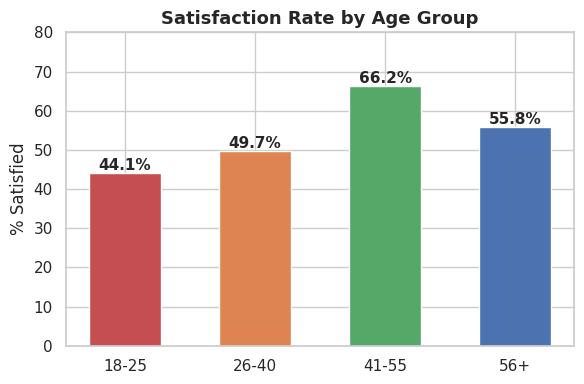

18-25 travellers are the least satisfied age group — likely driven by high expectations + economy class dominance.


In [11]:
# ── Chart 2: Age group ────────────────────────────────────────────────────────
age_sat = df.groupby('Age Group', observed=True)['target'].mean() * 100
fig, ax = plt.subplots(figsize=(6,4))
colors_age = ['#C44E52','#DD8452','#55A868','#4C72B0']
bars = ax.bar(age_sat.index.astype(str), age_sat.values, color=colors_age, edgecolor='white', width=0.55)
for bar, val in zip(bars, age_sat.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Satisfaction Rate by Age Group', fontsize=13, fontweight='bold')
ax.set_ylabel('% Satisfied'); ax.set_ylim(0,80); plt.tight_layout(); plt.show()
print("18-25 travellers are the least satisfied age group — likely driven by high expectations + economy class dominance.")


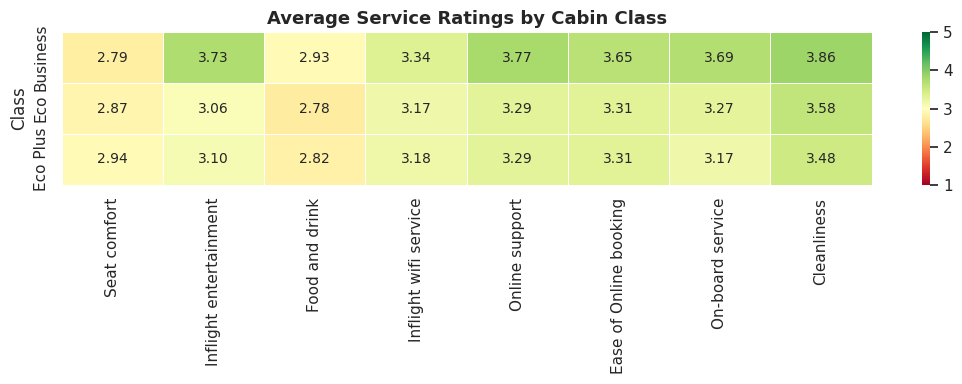

In [12]:
# ── Chart 3: Service rating heatmap by class ─────────────────────────────────
rating_cols = ['Seat comfort','Inflight entertainment','Food and drink','Inflight wifi service',
               'Online support','Ease of Online booking','On-board service','Cleanliness']
heatmap_data = df.groupby('Class')[rating_cols].mean()
fig, ax = plt.subplots(figsize=(11,4))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=1, vmax=5, linewidths=0.5, ax=ax, annot_kws={'size':10})
ax.set_title('Average Service Ratings by Cabin Class', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


In [13]:
# ── Chart 4: Cross-segment deep dive ─────────────────────────────────────────
hard = df.groupby(['Class','Type of Travel','Customer Type']).agg(
    Count=('target','count'),
    Sat_Rate=('target','mean'),
    Avg_Prob=('pred_prob','mean')
).reset_index().sort_values('Sat_Rate')
hard['Sat_Rate'] = (hard['Sat_Rate']*100).round(1)
hard['Avg_Prob'] = hard['Avg_Prob'].round(3)

print("HARDEST SEGMENTS TO SATISFY (bottom 6):")
print(hard.head(6).to_string(index=False))
print("\nEASIEST SEGMENTS (top 6):")
print(hard.tail(6).to_string(index=False))


HARDEST SEGMENTS TO SATISFY (bottom 6):
   Class  Type of Travel     Customer Type  Count  Sat_Rate  Avg_Prob
Business Personal Travel disloyal Customer     13       0.0     0.031
Eco Plus Personal Travel disloyal Customer      4       0.0     0.002
Eco Plus Business travel disloyal Customer    911       8.0     0.088
     Eco Business travel disloyal Customer  13450      14.4     0.145
     Eco Personal Travel disloyal Customer    184      17.4     0.141
Business Business travel disloyal Customer   9218      39.7     0.397

EASIEST SEGMENTS (top 6):
   Class  Type of Travel  Customer Type  Count  Sat_Rate  Avg_Prob
Eco Plus Business travel Loyal Customer   3991      46.4     0.461
Eco Plus Personal Travel Loyal Customer   4505      46.5     0.464
Business Personal Travel Loyal Customer   2660      46.7     0.472
     Eco Personal Travel Loyal Customer  32821      46.8     0.468
     Eco Business travel Loyal Customer  11854      47.6     0.476
Business Business travel Loyal Customer  

Disloyal Personal Travellers: 201 passengers, 15.9% satisfied


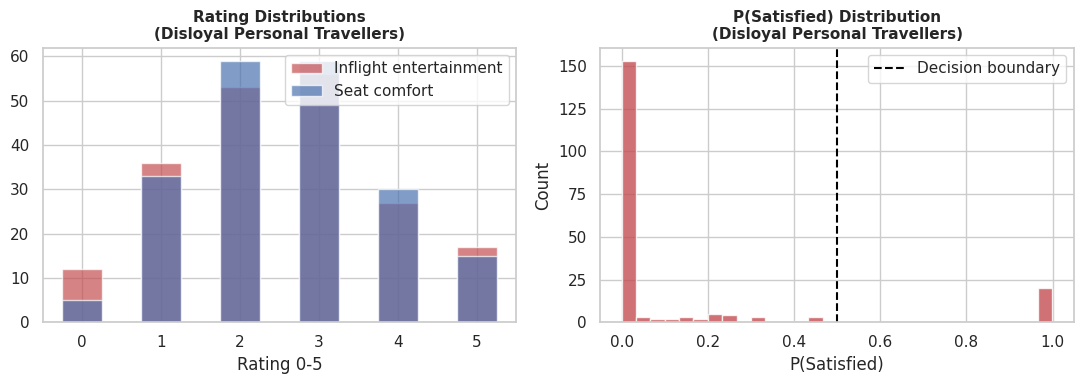

In [14]:
# ── Chart 5: Worst segment deep-dive ─────────────────────────────────────────
worst = df[(df['Customer Type']=='disloyal Customer') & (df['Type of Travel']=='Personal Travel')]
print(f"Disloyal Personal Travellers: {len(worst):,} passengers, {worst['target'].mean():.1%} satisfied")

fig, axes = plt.subplots(1,2, figsize=(11,4))
# Rating distributions
for col, color in [('Inflight entertainment','#C44E52'),('Seat comfort','#4C72B0')]:
    worst[col].value_counts().sort_index().plot(kind='bar', ax=axes[0], alpha=0.7, label=col, color=color)
axes[0].set_title('Rating Distributions\n(Disloyal Personal Travellers)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Rating 0-5'); axes[0].legend(); axes[0].tick_params(axis='x', rotation=0)

# Probability histogram
axes[1].hist(worst['pred_prob'], bins=30, color='#C44E52', alpha=0.8, edgecolor='white')
axes[1].axvline(0.5, color='black', linestyle='--', lw=1.5, label='Decision boundary')
axes[1].set_title('P(Satisfied) Distribution\n(Disloyal Personal Travellers)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('P(Satisfied)'); axes[1].set_ylabel('Count'); axes[1].legend()
plt.tight_layout(); plt.show()


---
## Part 4 — FastAPI Deployment

The trained XGBoost model is packaged into a production-ready REST API with:
- Single prediction endpoint (`POST /predict`) with confidence tier + actionable recommendation
- Batch prediction endpoint (`POST /predict/batch`, up to 1,000 passengers)
- Full Pydantic input validation with descriptive error messages
- Docker support for containerised deployment
- OpenAPI/Swagger docs auto-generated at `/docs`

### Architecture
```
POST /predict
      │
      ▼
PassengerInput (Pydantic validation)
      │
      ▼
build_feature_vector()  →  23-feature DataFrame
      │
      ▼
xgb.predict_proba()  →  P(satisfied)
      │
      ▼
Risk tier classification  →  PredictionResponse
```

### File structure
```
app/
├── main.py          # FastAPI app with all endpoints
├── model.pkl        # Serialised XGBoost (joblib, ~1.1 MB)
├── requirements.txt # Pinned dependencies
├── Dockerfile       # Container definition
└── README_API.md    # Usage guide
```


In [15]:
# ── API contract preview ──────────────────────────────────────────────────────
import json

request_example = {
    "customer_type": "loyal",
    "age": 42,
    "travel_type": "business",
    "flight_class": "Business",
    "flight_distance": 1500,
    "seat_comfort": 5,
    "timing_convenience": 4,
    "food_and_drink": 3,
    "gate_location": 3,
    "inflight_wifi": 4,
    "inflight_entertainment": 5,
    "online_support": 4,
    "ease_of_booking": 4,
    "onboard_service": 5,
    "leg_room": 4,
    "baggage_handling": 4,
    "checkin_service": 4,
    "cleanliness": 5,
    "online_boarding": 4,
    "departure_delay": 0,
    "arrival_delay": 0
}

response_example = {
    "satisfaction_probability": 0.9992,
    "predicted_class": "satisfied",
    "confidence": "Very High",
    "risk_tier": "Low Risk",
    "recommendation": "Passenger is very likely satisfied. Include in NPS champion outreach."
}

print("REQUEST:")
print(json.dumps(request_example, indent=2))
print("\nRESPONSE:")
print(json.dumps(response_example, indent=2))


REQUEST:
{
  "customer_type": "loyal",
  "age": 42,
  "travel_type": "business",
  "flight_class": "Business",
  "flight_distance": 1500,
  "seat_comfort": 5,
  "timing_convenience": 4,
  "food_and_drink": 3,
  "gate_location": 3,
  "inflight_wifi": 4,
  "inflight_entertainment": 5,
  "online_support": 4,
  "ease_of_booking": 4,
  "onboard_service": 5,
  "leg_room": 4,
  "baggage_handling": 4,
  "checkin_service": 4,
  "cleanliness": 5,
  "online_boarding": 4,
  "departure_delay": 0,
  "arrival_delay": 0
}

RESPONSE:
{
  "satisfaction_probability": 0.9992,
  "predicted_class": "satisfied",
  "confidence": "Very High",
  "risk_tier": "Low Risk",
  "recommendation": "Passenger is very likely satisfied. Include in NPS champion outreach."
}


In [16]:
# ── Local deployment instructions ─────────────────────────────────────────────
print("""
DEPLOYMENT GUIDE
================

1. LOCAL (Python)
   pip install -r app/requirements.txt
   cd app && uvicorn main:app --reload --port 8000
   Open: http://localhost:8000/docs

2. DOCKER
   docker build -t satisfaction-api ./app
   docker run -d -p 8000:8000 --name sat-api satisfaction-api
   curl http://localhost:8000/health

3. CLOUD (e.g. Render / Railway)
   - Push app/ folder to GitHub
   - Set start command: uvicorn main:app --host 0.0.0.0 --port $PORT
   - Free tier handles ~100 req/s

4. THRESHOLD TUNING
   # Lower threshold to catch more dissatisfied passengers (higher recall):
   prob = model.predict_proba(X)[0,1]
   pred = 'satisfied' if prob >= 0.40 else 'dissatisfied'  # threshold=0.40
   # Trade-off: more false positives, fewer missed dissatisfied passengers
""")



DEPLOYMENT GUIDE

1. LOCAL (Python)
   pip install -r app/requirements.txt
   cd app && uvicorn main:app --reload --port 8000
   Open: http://localhost:8000/docs

2. DOCKER
   docker build -t satisfaction-api ./app
   docker run -d -p 8000:8000 --name sat-api satisfaction-api
   curl http://localhost:8000/health

3. CLOUD (e.g. Render / Railway)
   - Push app/ folder to GitHub
   - Set start command: uvicorn main:app --host 0.0.0.0 --port $PORT
   - Free tier handles ~100 req/s

4. THRESHOLD TUNING
   # Lower threshold to catch more dissatisfied passengers (higher recall):
   prob = model.predict_proba(X)[0,1]
   pred = 'satisfied' if prob >= 0.40 else 'dissatisfied'  # threshold=0.40
   # Trade-off: more false positives, fewer missed dissatisfied passengers



---
## Summary — Full Pipeline Results

### Model Performance

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | 82.9% | 84.4% | 84.3% | 84.4% | 90.4% |
| Random Forest | 95.1% | 95.5% | 95.1% | 95.3% | 99.1% |
| XGBoost (baseline) | 96.2% | 96.2% | 96.1% | 96.1% | 99.4% |
| **XGBoost (tuned)** | **96.2%** | **96.9%** | **95.3%** | **96.1%** | **99.4%** |

### SHAP Insights
- **Seat Comfort** has the highest mean |SHAP| value — it's the most consistently impactful feature at the *individual level*
- **Inflight Entertainment** shows the sharpest cliff: rating ≥ 4 is a strong satisfier; ≤ 2 is a strong dissatisfier
- The **loyalty × entertainment interaction** is significant: disloyal passengers penalise poor entertainment more severely

### Hardest Segments to Satisfy
1. **Eco disloyal business travellers** — 14.4% satisfied (13,450 passengers at risk)
2. **Eco disloyal personal travellers** — 17.4% satisfied
3. **Eco Plus disloyal business travellers** — 8.0% satisfied

### Business Priority (Updated with Segment Data)
1. Entertainment upgrade → targets all segments, highest SHAP impact
2. Disloyal Economy retention programme → 37pp satisfaction gap, 13K+ at-risk passengers  
3. 18-25 experience redesign → lowest age-group satisfaction, fastest-growing travel segment
4. Digital UX overhaul → online booking + boarding cluster drives compound effect
